Name: Mehak Jain;
Roll No.: MA25M013;
Project Name: Agriculture Project

In [3]:
%pip install geopandas


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [5]:
# Uploading the datafile.

crop_df = pd.read_csv("APY.csv")

In [6]:
# Basic Analysis

crop_df.head()
crop_df.tail()
crop_df.shape
crop_df.info()
crop_df.describe()
crop_df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  str    
 1   District    345336 non-null  str    
 2   Crop        345327 non-null  str    
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  str    
 5   Area        345336 non-null  float64
 6   Production  340388 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 21.1 MB


State             str
District          str
Crop              str
Crop_Year       int64
Season            str
Area          float64
Production    float64
Yield         float64
dtype: object

In [56]:
# Checking for null entries

crop_df.isnull().sum()

State         0
District      0
Crop          5
Crop_Year     0
Season        0
Area          0
Production    0
Yield         0
dtype: int64

In [75]:
# Cleaning the data for analysis.

crop_df = crop_df.dropna(subset = ['Production'])
crop_df = crop_df.dropna(subset = ['Crop'])
crop_df['Season'] = crop_df['Season'].str.strip() # To remove leading and trailing spaces from "Season" feature.

In [9]:
# Find the state which has the most production during Rabi Season for all years.

Rabi_Season = crop_df[crop_df['Season'] == 'Rabi']
Rabi_State = Rabi_Season.groupby(['Crop_Year', 'State'])['Production'].sum().reset_index()
Per_Year = Rabi_State.loc[Rabi_State.groupby('Crop_Year')['Production'].idxmax()]
for _, i in Per_Year.iterrows():
    print(f"State with most production during Rabi season for year {int(i['Crop_Year'])} is {i['State']} with {i['Production']:,.2f} units.")

State with most production during Rabi season for year 1997 is West Bengal with 39,560,537.00 units.
State with most production during Rabi season for year 1998 is Uttar Pradesh with 26,459,608.00 units.
State with most production during Rabi season for year 1999 is Uttar Pradesh with 28,433,525.00 units.
State with most production during Rabi season for year 2000 is Uttar Pradesh with 27,878,257.00 units.
State with most production during Rabi season for year 2001 is Uttar Pradesh with 28,469,581.00 units.
State with most production during Rabi season for year 2002 is Uttar Pradesh with 26,541,213.00 units.
State with most production during Rabi season for year 2003 is Uttar Pradesh with 29,413,273.00 units.
State with most production during Rabi season for year 2004 is Uttar Pradesh with 34,871,481.00 units.
State with most production during Rabi season for year 2005 is Uttar Pradesh with 35,299,707.00 units.
State with most production during Rabi season for year 2006 is Uttar Prades

In [10]:
# Find the district which has the most yield during Kharif Season for all years.

Kharif_Season = crop_df[crop_df['Season'] == 'Kharif']
Kharif_District = Kharif_Season.groupby(['Crop_Year', 'District '])['Yield'].sum().reset_index()
Per_Year = Kharif_District.loc[Kharif_District.groupby('Crop_Year')['Yield'].idxmax()]
for _, i in Per_Year.iterrows():
    print(f"District with most yield during Kharif season for year {int(i['Crop_Year'])} is {i['District ']} with {i['Yield']:,.2f} units.")

District with most yield during Kharif season for year 1997 is KOLHAPUR with 243.75 units.
District with most yield during Kharif season for year 1998 is DADRA AND NAGAR HAVELI with 380.18 units.
District with most yield during Kharif season for year 1999 is DADRA AND NAGAR HAVELI with 430.81 units.
District with most yield during Kharif season for year 2000 is DADRA AND NAGAR HAVELI with 467.90 units.
District with most yield during Kharif season for year 2001 is DADRA AND NAGAR HAVELI with 281.18 units.
District with most yield during Kharif season for year 2002 is DADRA AND NAGAR HAVELI with 283.06 units.
District with most yield during Kharif season for year 2003 is DADRA AND NAGAR HAVELI with 262.65 units.
District with most yield during Kharif season for year 2004 is DADRA AND NAGAR HAVELI with 263.56 units.
District with most yield during Kharif season for year 2005 is DADRA AND NAGAR HAVELI with 265.79 units.
District with most yield during Kharif season for year 2006 is DADRA 

In [11]:
# Find the drought year.
# A drought year would typically show significantly lower production compared to other years.

Production = crop_df.groupby('Crop_Year')['Production'].agg([('Total_Production', 'sum')]).reset_index()
Drought_Year = Production.loc[Production['Total_Production'].idxmin()]
print(f"The drought year was {int(Drought_Year.iloc[0])} with {Drought_Year['Total_Production']:,.2f} units.")

The drought year was 2020 with 10,177,226.00 units.


In [12]:
# Find the state which produces most rice and most sugarcane.

Rice_Crop = crop_df[crop_df['Crop'] == 'Rice']
Rice_State = Rice_Crop.groupby('State')['Production'].sum()
print("State with most Rice Production is", Rice_State.idxmax(), 'with', Rice_State.max(), 'units.\n')

SC_Crop = crop_df[crop_df['Crop'] == 'Sugarcane']
SC_State = SC_Crop.groupby('State')['Production'].sum()
print("State with most Sugarcane Production is", SC_State.idxmax(), 'with', SC_State.max(), 'units.')

State with most Rice Production is West Bengal with 338984869.0 units.

State with most Sugarcane Production is Uttar Pradesh with 3062485896.0 units.


In [144]:
# 5 more problem statements to display information about the analysis of the statement.

# 1. Which state have the highest total agricultural production, and how has their output changed over the 24-year period?
state_production = crop_df.groupby("State")['Production'].sum()
print(f'The state with the highest total agricultural production is {state_production.idxmax()} with {state_production.max()} units.')
# we can pbserve that Kerala has the highest total agricultural production.
# in order to assess the output change over the years, we will use Cumulative Growth (CAGR) - i.e. the compound annual growth rate from a start year to and end year.
kerala_production = crop_df[crop_df['State'] == 'Kerala'].groupby("Crop_Year")['Production'].agg([('Total_Production', 'sum')]).reset_index()
n = kerala_production['Crop_Year'].max() - kerala_production['Crop_Year'].min()
cagr = ((kerala_production.iloc[-1]['Total_Production'])/(kerala_production.iloc[0]['Total_Production']))**(1/n)-1
print(f"It's output has changed by {cagr*100:.2f}% per year (CAGR).\n")

# 2. Which crops dominate by cultivated area vs. by yield efficiency — and are the most widely grown crops also the most productive?
crop_by_area = crop_df.groupby("Crop")['Area '].sum()
crop_by_yield = crop_df.groupby("Crop")['Yield'].sum()
crop_by_production = crop_df.groupby("Crop")['Production'].sum()
print(f"The crop that dominated by cultivated area is {crop_by_area.idxmax()} with {crop_by_area.max()} units, whereas, the crop that dominated by yield efficiency is {crop_by_yield.idxmax()} with {crop_by_yield.max()} units.")
print(f'And the most productive crop is {crop_by_production.idxmax()} with {crop_by_production.max()} units.')
print('We can observe that Coconut is both "Most Productive" and also dominates in terms of "Yield Efficiency".\n')

# 3. How does average crop yield vary across seasons, and which season consistently delivers the best results?
# seasons are - rabi, kharif, autumn, summer, winter
# we will judge the best results based on the highest average to measure consistency.
seasons = crop_df['Season'].unique()
seasons_average = crop_df.groupby('Season')['Yield'].agg([('Average_Yield', 'mean')]).drop('Whole Year')
for i in seasons:
    if i=='Whole Year': # we are not considering "Whole Year".
        continue
    print(f'Average yield in the season {i} was {seasons_average.loc[i, 'Average_Yield']:.2f} units.')
print(f'The season that consistently delivered the best results was {seasons_average['Average_Yield'].idxmax()} with {seasons_average['Average_Yield'].max()} units.\n')

# 4. Which crop show the most significant yield improvement over time, and is there any crop in long-term decline?
yield_improvement = crop_df.groupby(['Crop', 'Crop_Year'])['Yield'].agg([('Total_Production', 'mean')]).reset_index()
best = 0
worst = float('inf')
m = ''
j = ''
crops = crop_df['Crop'].unique()
for i in crops:
    crop_cagr = yield_improvement[yield_improvement['Crop'] == i]
    if len(crop_cagr) < 2:
        continue
    n = crop_cagr['Crop_Year'].max() - crop_cagr['Crop_Year'].min()
    if n == 0:
        continue
    cagr = ((crop_cagr.iloc[-1]['Total_Production'])/(crop_cagr.iloc[0]['Total_Production']))**(1/n)-1
    if cagr>best:
        best = cagr
        j = i
    if cagr<worst:
        worst = cagr
        m = i
print(f'The crop with the most significant yield improvement over time is {j} with CAGR {best*100:.2f}%.')
print(f'The crop that faced decline over time is {i} with CAGR {worst*100:.2f}%.\n')

# 5. Are there states and/or districts where cultivated area is large but yield is consistently below the national average — indicating underperforming agricultural regions?
national_avg = crop_df['Yield'].mean()
large_area = crop_df['Area '].mean()
state = crop_df['State'].unique()
district = crop_df['District '].unique()
yield_state = crop_df.groupby('State')['Yield'].agg([('Avg_Yield', 'mean')])
area_state = crop_df.groupby('State')['Area '].agg([('Avg_Area', 'mean')])
yield_district = crop_df.groupby('District ')['Yield'].agg([('Avg_Yield', 'mean')])
area_district = crop_df.groupby('District ')['Area '].agg([('Avg_Area', 'mean')])
print('The underperforming states are ', end = '')
for i in state:
    if yield_state.loc[i, 'Avg_Yield']<national_avg and area_state.loc[i, 'Avg_Area']>large_area:
        print(i, end=', ')
print('\nThe underperforming districts are ', end = '')
for i in district:
    if yield_district.loc[i, 'Avg_Yield']<national_avg and area_district.loc[i, 'Avg_Area']>large_area:
        print(i, end=', ')

The state with the highest total agricultural production is Kerala with 129700649853.0 units.
It's output has changed by -0.36% per year (CAGR).

The crop that dominated by cultivated area is Rice with 995002381.5 units, whereas, the crop that dominated by yield efficiency is Coconut  with 25854916.08 units.
And the most productive crop is Coconut  with 310804772578.0 units.
We can observe that Coconut is both "Most Productive" and also dominates in terms of "Yield Efficiency".

Average yield in the season Kharif was 2.40 units.
Average yield in the season Rabi was 2.25 units.
Average yield in the season Autumn was 2.45 units.
Average yield in the season Summer was 3.36 units.
Average yield in the season Winter was 6.05 units.
The season that consistently delivered the best results was Winter with 6.045747754309299 units.

The crop with the most significant yield improvement over time is Oilseeds total with CAGR 7.96%.
The crop that faced decline over time is Other Summer Pulses with C

In [15]:
# If I was a crop insurance agent, which crop I would have recommended for insurance and why?

print("As a crop insurance agent, I would consider Yield Variability because it directly measures harvest unpredictability.\n")
Yield = crop_df.groupby("Crop")['Yield'].agg([('Mean', 'mean'), ('Std Dev', 'std'), ('Count', 'count')]).reset_index()
Yield['Coefficient of Variation'] = (Yield['Std Dev']/Yield['Mean']) * 100
Yield_Analysis = Yield.sort_values('Coefficient of Variation', ascending = False)
print(f"The crop I would have recommended for insurance is {Yield_Analysis.iloc[0]['Crop']} with Coefficient of Variation {Yield_Analysis.iloc[0]['Coefficient of Variation']:.2f}.")

As a crop insurance agent, I would consider Yield Variability because it directly measures harvest unpredictability.

The crop I would have recommended for insurance is Cashewnut with Coefficient of Variation 3590.78.


In [16]:
# What would be my recommendation to farmers to produce a particular crop for a particular year?

print("I would recommend the crop with the highest production in that year.\n")
years = sorted(crop_df['Crop_Year'].dropna().unique())
for i in years:
    Crop_Yr = crop_df[crop_df['Crop_Year'] == i]
    Crop_Prod = Crop_Yr.groupby('Crop')['Production'].sum()
    print(f'Corresponding to Year {int(i)}, I would recommend {Crop_Prod.idxmax()} with production {Crop_Prod.max()}.')

I would recommend the crop with the highest production in that year.

Corresponding to Year 1997, I would recommend Coconut  with production 5643107340.0.
Corresponding to Year 1998, I would recommend Coconut  with production 7332635150.0.
Corresponding to Year 1999, I would recommend Coconut  with production 7975607700.0.
Corresponding to Year 2000, I would recommend Coconut  with production 9096443079.0.
Corresponding to Year 2001, I would recommend Coconut  with production 8839857650.0.
Corresponding to Year 2002, I would recommend Coconut  with production 11978425235.0.
Corresponding to Year 2003, I would recommend Coconut  with production 11880727860.0.
Corresponding to Year 2004, I would recommend Coconut  with production 13398613962.0.
Corresponding to Year 2005, I would recommend Coconut  with production 14453706228.0.
Corresponding to Year 2006, I would recommend Coconut  with production 15156616015.0.
Corresponding to Year 2007, I would recommend Coconut  with production 1388

In [100]:
# Create a piece of software to get the following input (Year, Season, Crop, Production) and provide the analysis of yields for the entire nation.

year = int(input("Enter a year: "))
season = input("Enter a season: ").strip().lower()
crop = input("Enter a crop: ").strip().lower()
production = int(input("Enter a minimum production: "))
filtered = crop_df[(crop_df['Crop_Year'] == year) & (crop_df['Season'].str.strip().str.lower() == season) & (crop_df['Crop'].str.strip().str.lower() == crop) & (crop_df['Production'].fillna(0) >= production)]
if filtered.empty:
    print("Incorrect input or no data found for the selected filters!")
else:
    avg_yield = filtered['Yield'].mean()
    national_avg = crop_df['Yield'].mean()
    difference = avg_yield - national_avg
    print(f"For Year = {year}, Season = {season}, Crop = {crop} and Minimum Production = {production}: ")
    print(f"Average Yield : {avg_yield:.2f}")
    print(f"National Average Yield : {national_avg:.2f}")
    print(f"Difference : {difference:.2f} ({'above' if difference > 0 else "below"} national average)")

Enter a year:  2004
Enter a season:  kharif
Enter a crop:  coconut
Enter a minimum production:  9


For Year = 2004, Season = kharif, Crop = coconut and Minimum Production = 9: 
Average Yield : 249.73
National Average Yield : 80.58
Difference : 169.15 (above national average)


In [104]:
# Categorical Data Analysis
# There are 4 categorical variables - State, District, Crop, Season

print(f'There are {crop_df['State'].nunique()} unique values in State feature.')
print(f'There are {crop_df['District '].nunique()} unique values in District feature.')
print(f'There are {crop_df['Crop'].nunique()} unique values in Crop feature.')
print(f'There are {crop_df['Season'].nunique()} unique values in Season feature.')
print('---------------------------------------------------')
print(f'Most common state is {crop_df['State'].mode()[0]}.')
print(f'Most common district is {crop_df['District '].mode()[0]}.')
print(f'Most common crop is {crop_df['Crop'].mode()[0]}.')
print(f'Most common season is {crop_df['Season'].mode()[0]}.')
print('---------------------------------------------------')
pd.crosstab(crop_df['State'], crop_df['District '])
pd.crosstab(crop_df['State'], crop_df['Crop'])
pd.crosstab(crop_df['State'], crop_df['Season'])
pd.crosstab(crop_df['District '], crop_df['Crop'])
pd.crosstab(crop_df['District '], crop_df['Season'])
pd.crosstab(crop_df['Crop'], crop_df['Season'])

There are 37 unique values in State feature.
There are 707 unique values in District feature.
There are 55 unique values in Crop feature.
There are 6 unique values in Season feature.
---------------------------------------------------
Most common state is Uttar Pradesh.
Most common district is BILASPUR.
Most common crop is Rice.
Most common season is Kharif.
---------------------------------------------------


Season,Autumn,Kharif,Rabi,Summer,Whole Year,Winter
Crop,,,,,,
Arecanut,2,40,369,2,1737,0
Arhar/Tur,18,9578,857,30,239,42
Bajra,0,6541,493,572,485,0
Banana,8,273,7,453,3294,7
Barley,0,352,5408,0,48,0
Black pepper,2,21,93,2,1252,0
Cardamom,0,17,0,0,466,0
Cashewnut,0,147,55,0,1317,0
Castor seed,0,4021,310,0,165,0


In [19]:
%pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: /Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


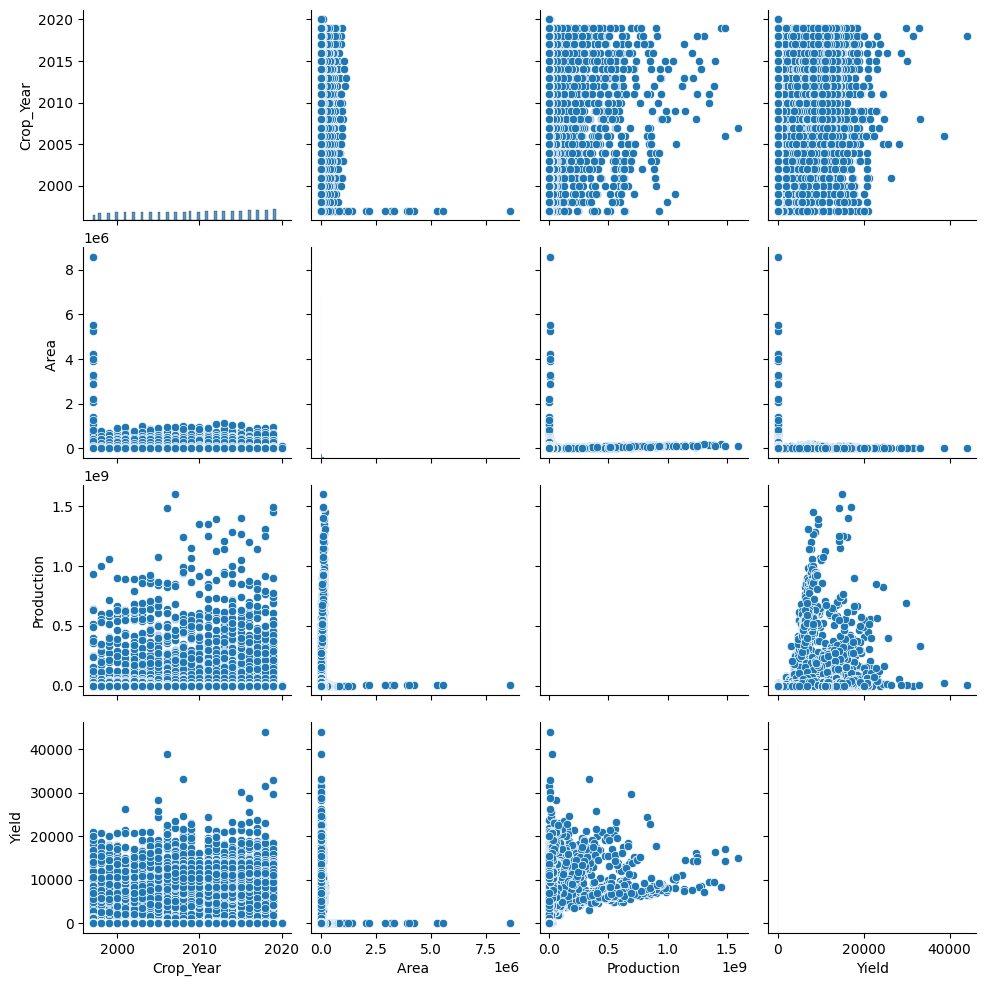

In [159]:
# Paiplot usin KDE

import seaborn
seaborn.pairplot(crop_df)
plt.show()

            Crop_Year     Area   Production    Yield
Crop_Year    1.000000 -0.024108    0.004051  0.00865
Area        -0.024108  1.000000    0.048521  0.00013
Production   0.004051  0.048521    1.000000  0.43740
Yield        0.008650  0.000130    0.437400  1.00000


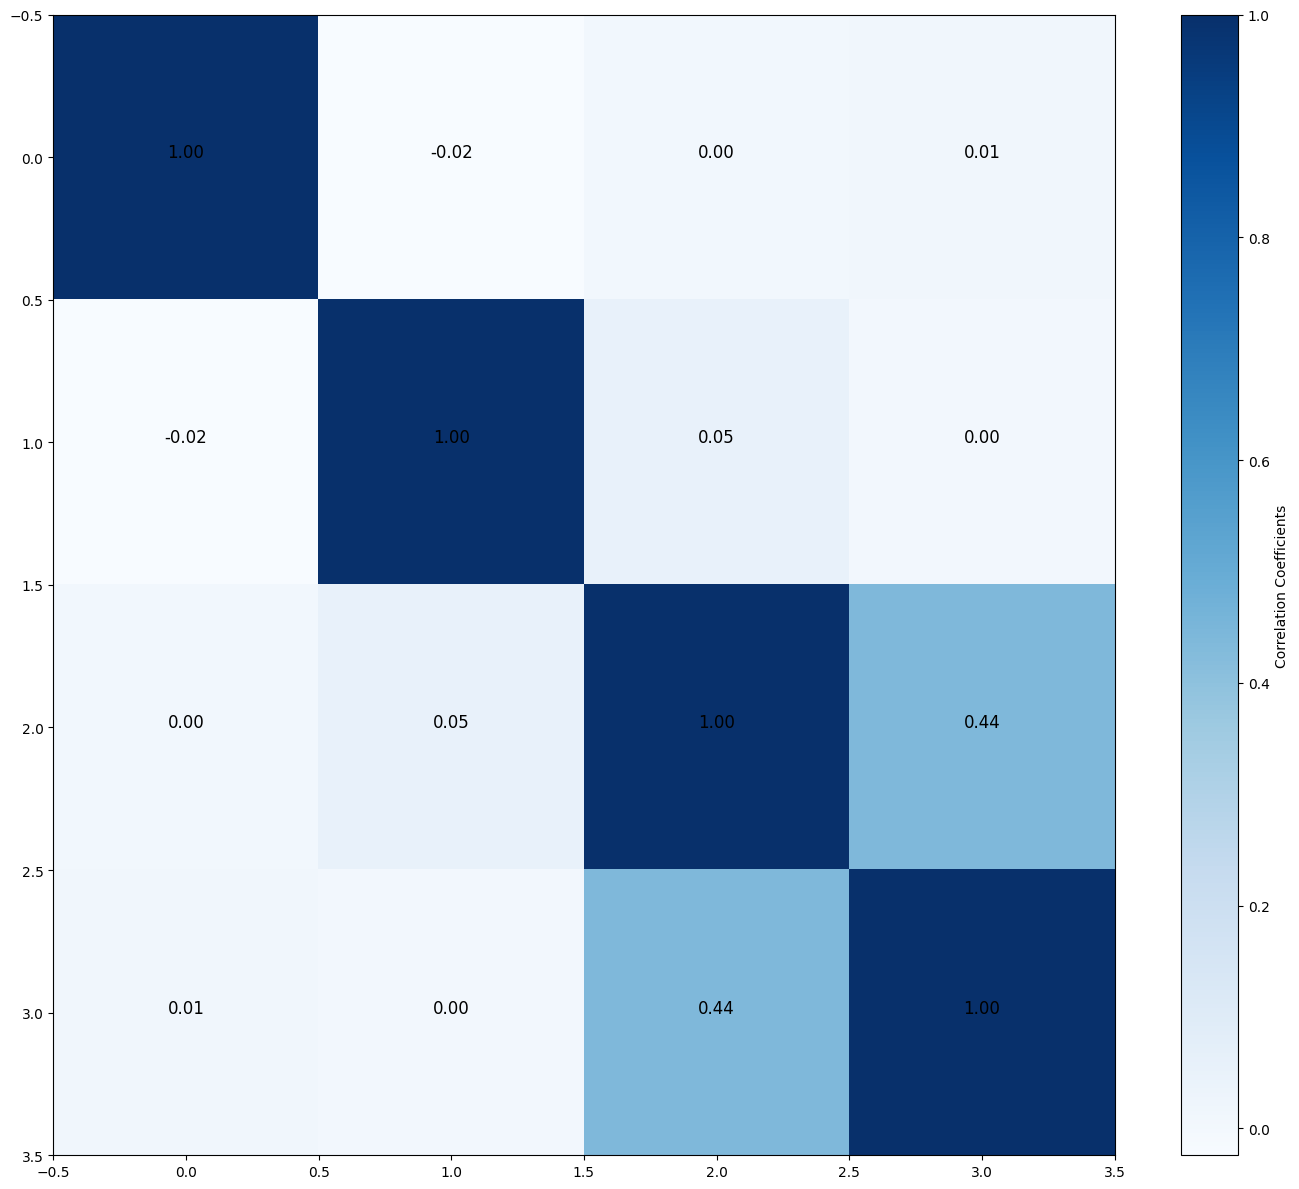

In [21]:
# Correlation between each variable and their heatmap

numerical_cols = crop_df.select_dtypes(include = [np.number]).columns
correlation_matrix = crop_df[numerical_cols].corr()
print(correlation_matrix)

fig, ax = plt.subplots(figsize = (14, 12))
image = ax.imshow(correlation_matrix, cmap = 'Blues', aspect = 'auto')
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha = 'center', color = 'k', fontsize = 12)
plt.colorbar(image, ax = ax, label = 'Correlation Coefficients')
plt.tight_layout()
plt.show()

/var/folders/69/4jsgxhp9043gyr_4frr0mxk40000gn/T/ipykernel_34275/1773932098.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = crop_df.select_dtypes(include = [object]).columns


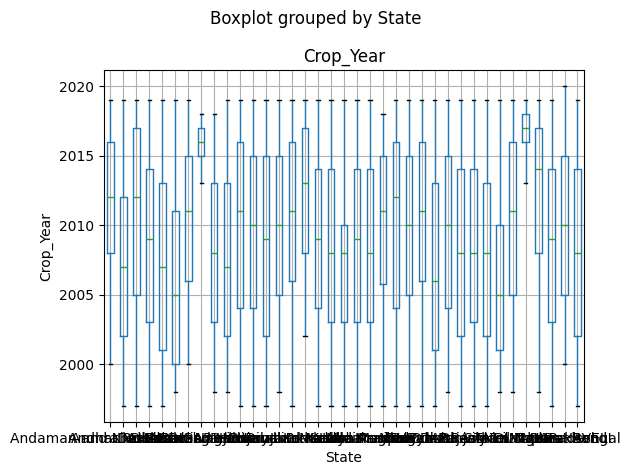

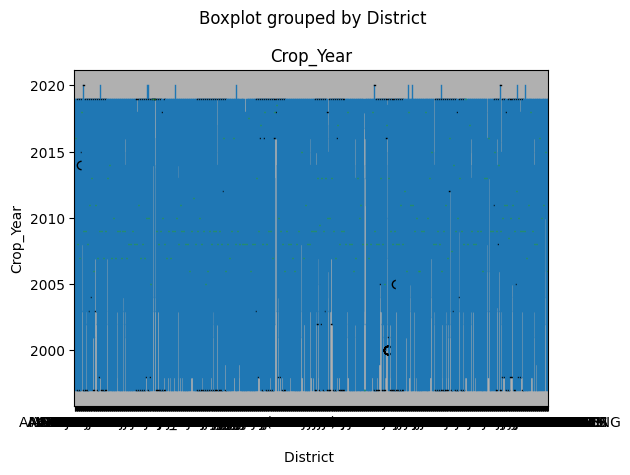

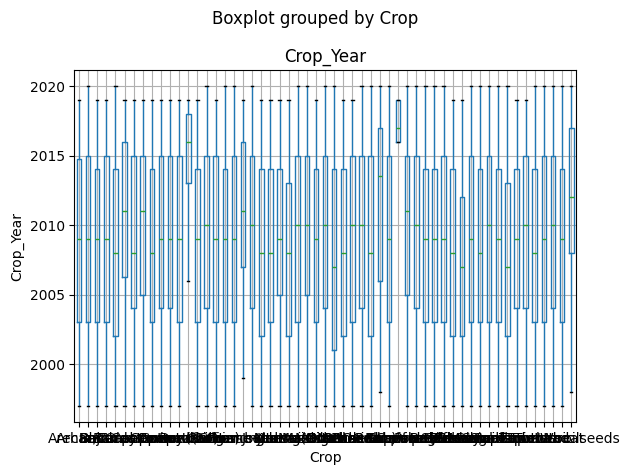

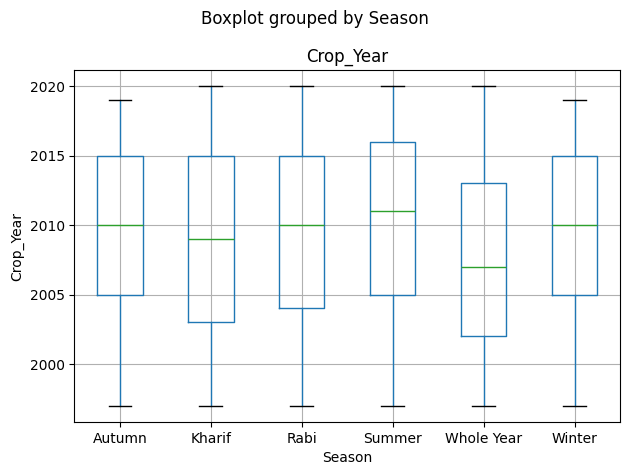

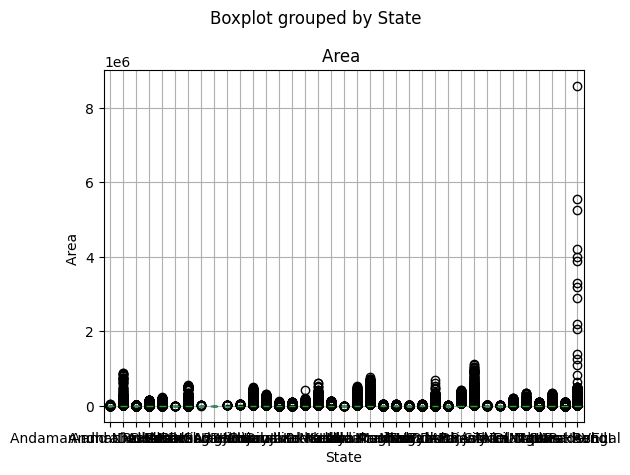

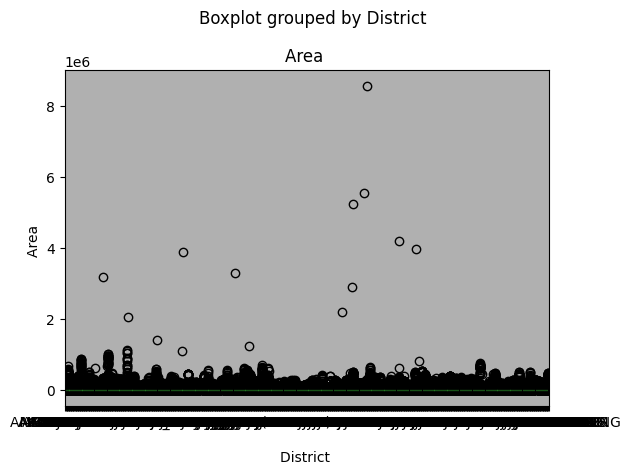

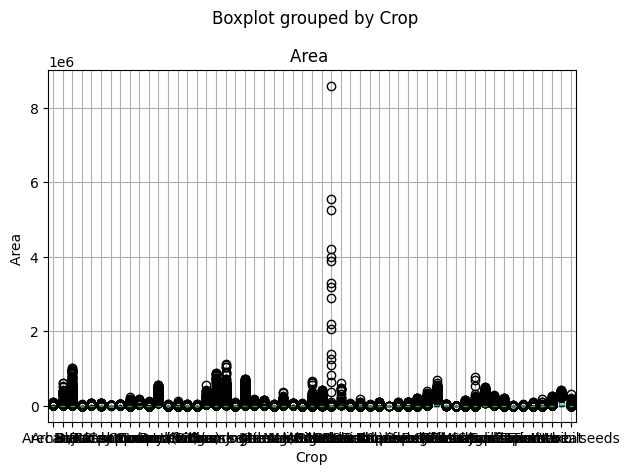

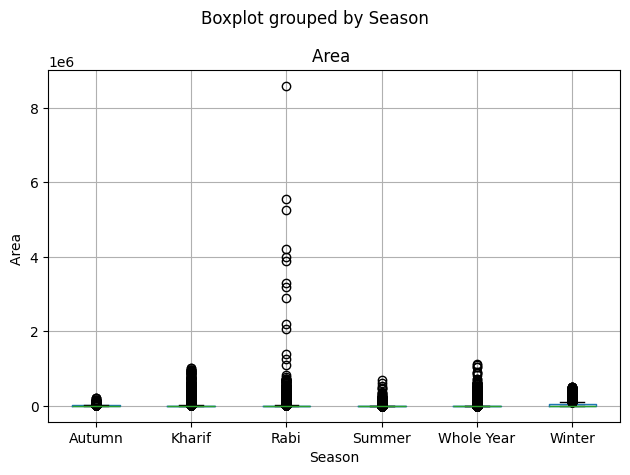

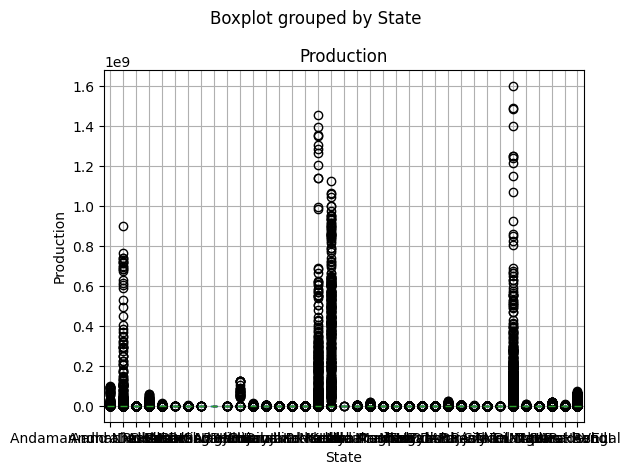

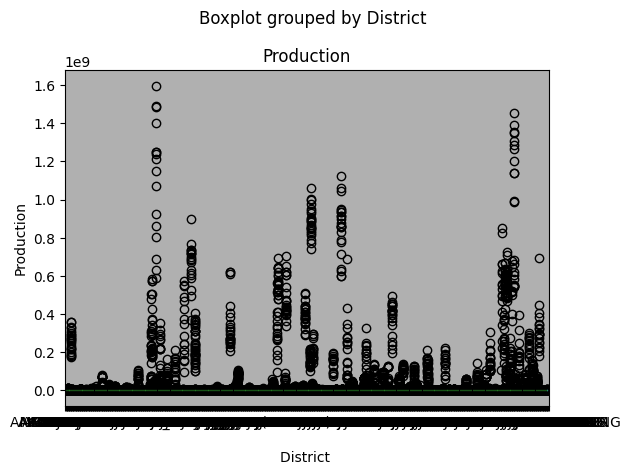

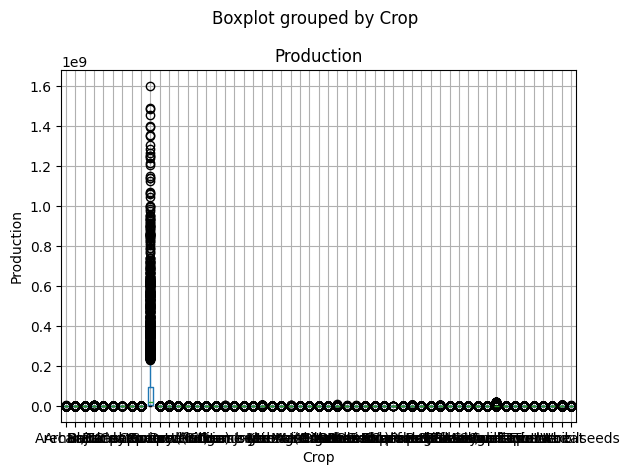

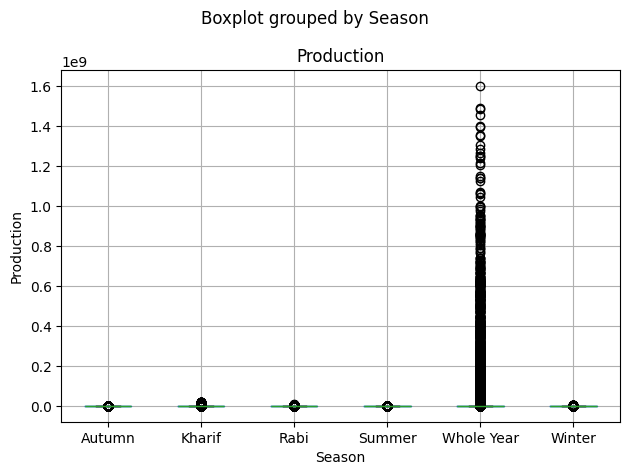

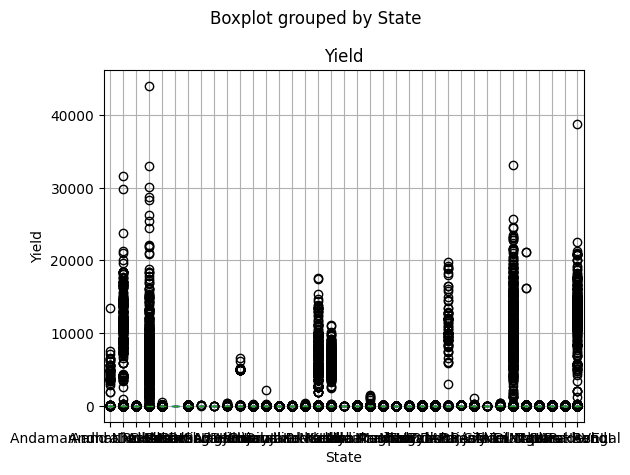

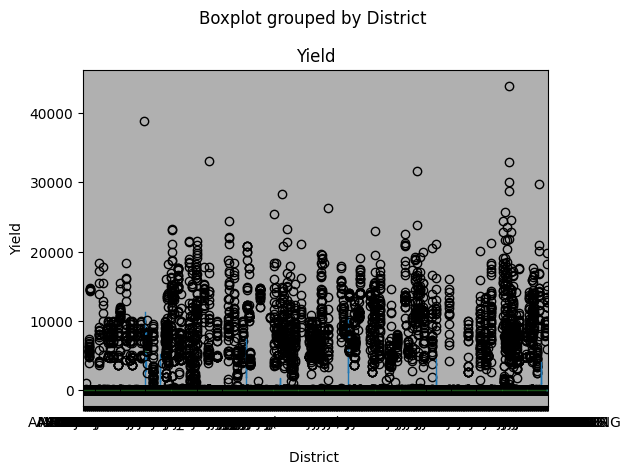

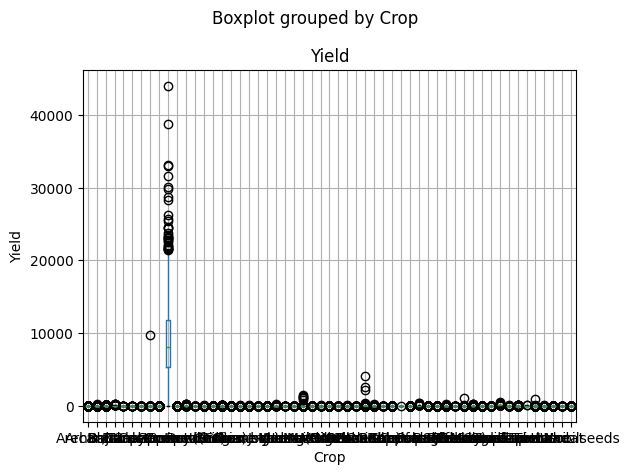

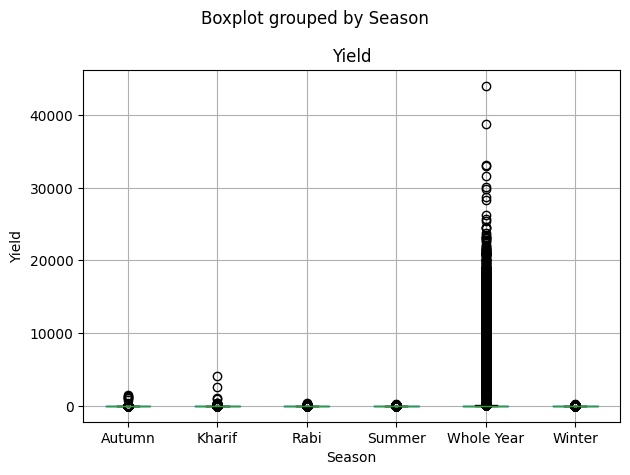

In [22]:
# Boxplot for each column

numerical_cols = crop_df.select_dtypes(include = [np.number]).columns
categorical_cols = crop_df.select_dtypes(include = [object]).columns
for i in numerical_cols:
    for j in categorical_cols:
        crop_df.boxplot(column = i, by = j)
        plt.ylabel(f'{i}')
        plt.xlabel(f'{j}')
        plt.tight_layout()
        plt.show()

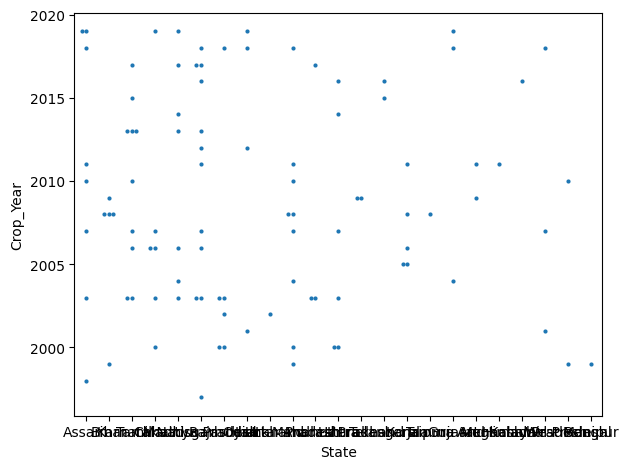

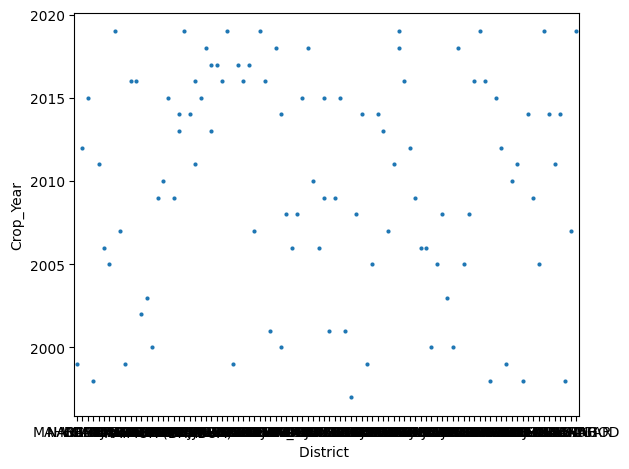

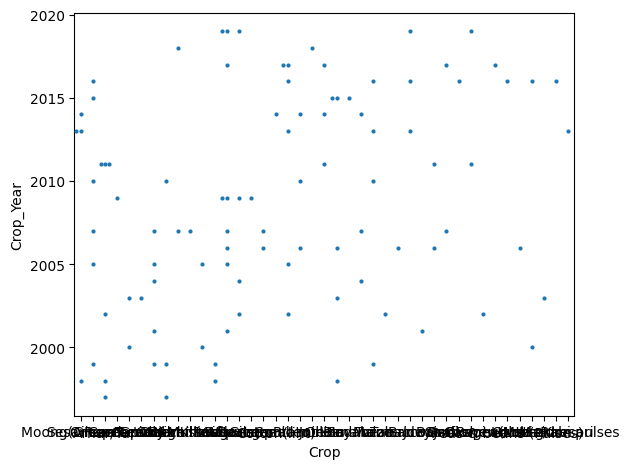

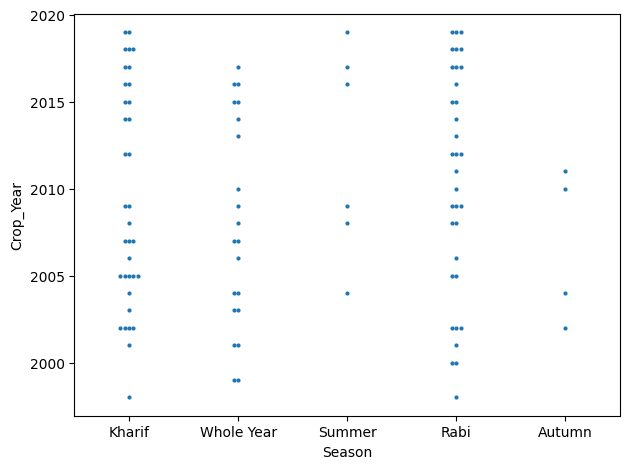

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be p

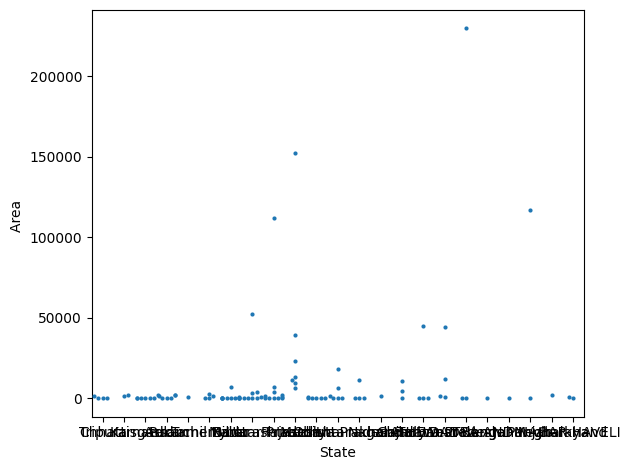

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


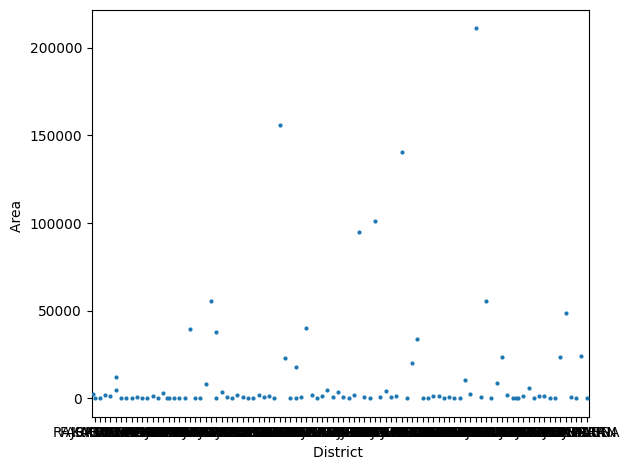

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 18.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be p

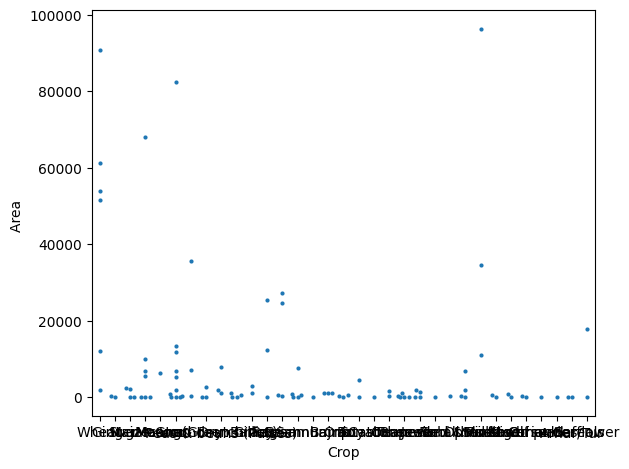

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 16.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 32.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 12.0% of the points cannot be p

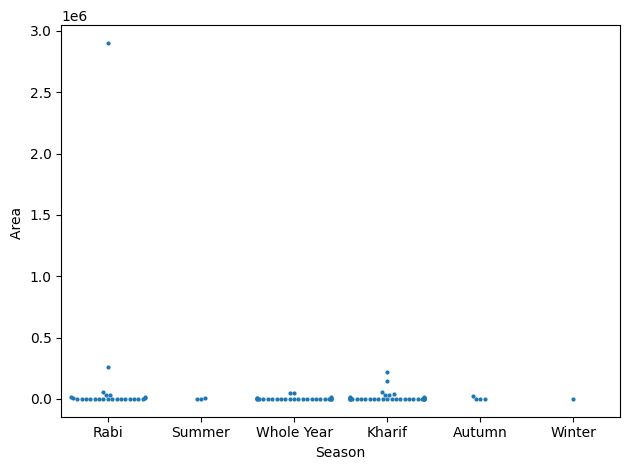

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 68.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 70.0% of the points cannot be p

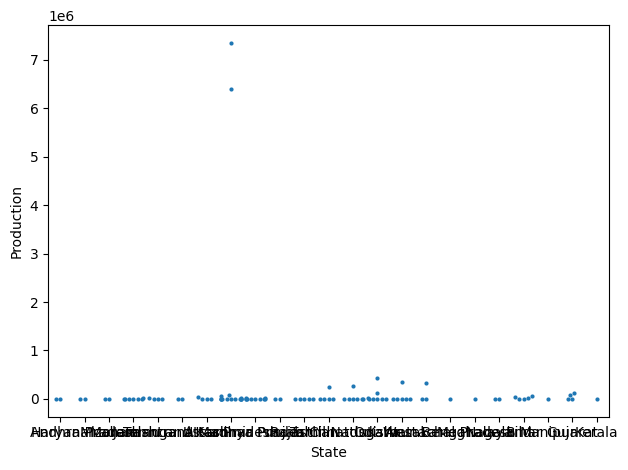

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


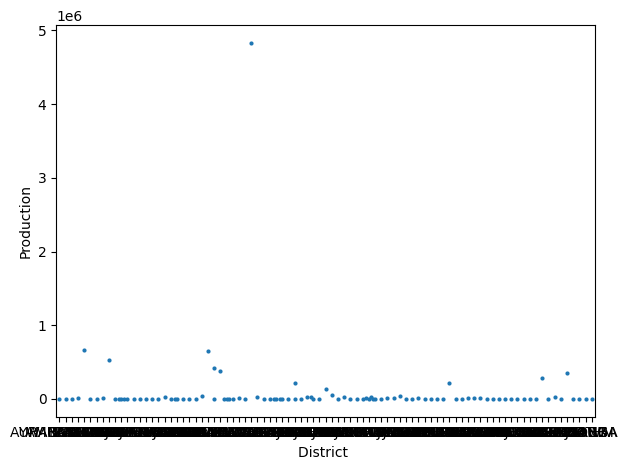

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 66.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be p

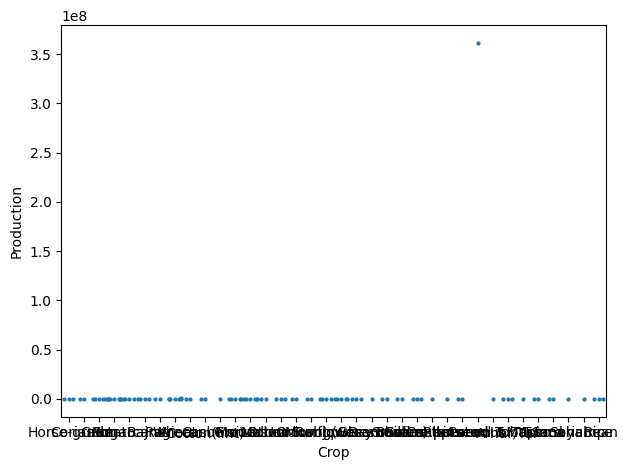

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 36.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 27.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


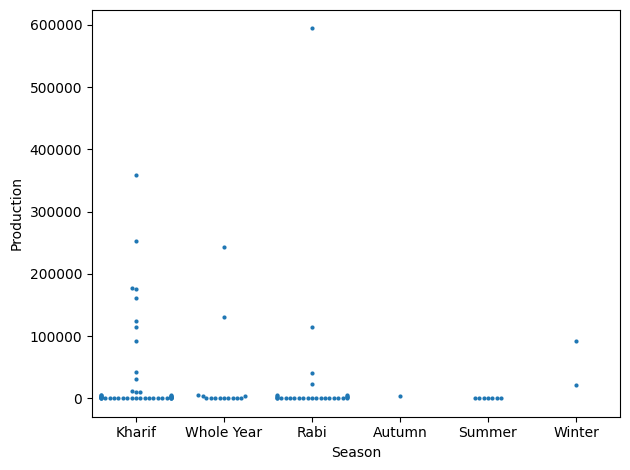

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 55.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 70.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be p

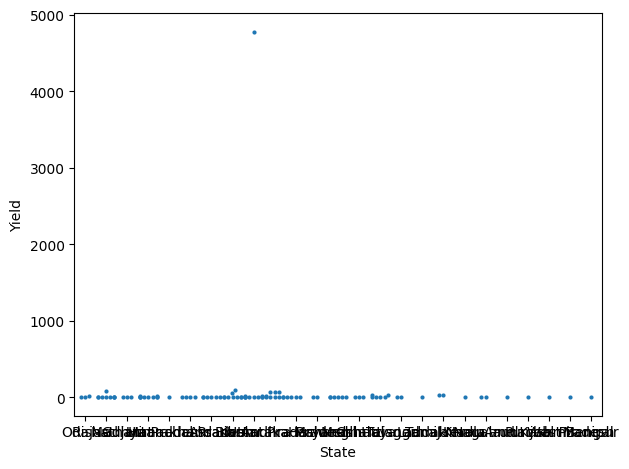

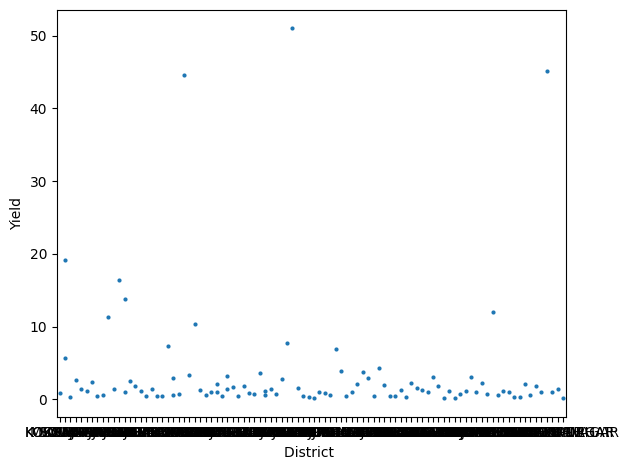

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 70.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be p

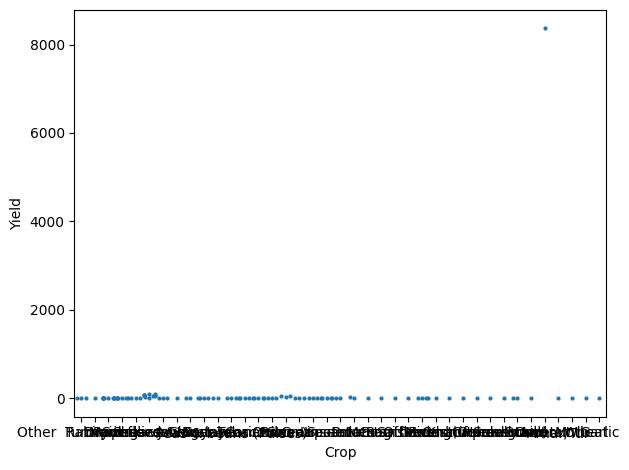

/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 63.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/mehakjain/PycharmProjects/AgricultureProject_MA25M013/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 15.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


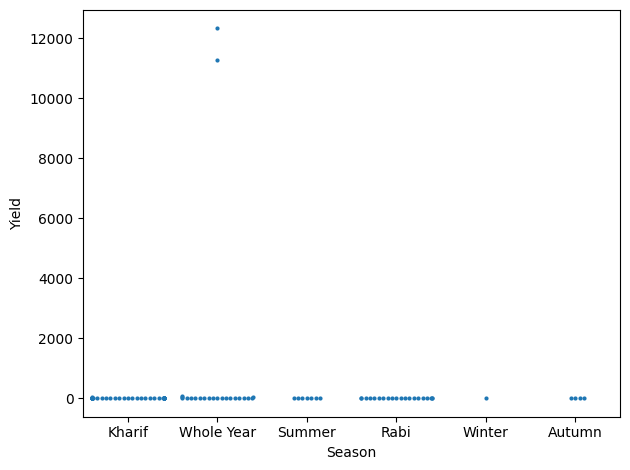

In [23]:
# Swarmplot for each column

for i in numerical_cols:
    for j in categorical_cols:
        seaborn.swarmplot(x = j, y = i, data = crop_df.sample(100), size = 3)
        plt.tight_layout()
        plt.show()

In [24]:
# Calculating outliers and simple statistics and simple statistics

for i in numerical_cols:
    Q1  = crop_df[i].quantile(0.25)
    Q3  = crop_df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = crop_df[(crop_df[i] < lower_fence) | (crop_df[i] > upper_fence)]
    print(f'{i}: {len(outliers)} outliers')

crop_df.describe()

Crop_Year: 0 outliers
Area : 56520 outliers
Production: 60094 outliers
Yield: 51392 outliers


,Crop_Year,Area,Production,Yield
count,340388.000000,3.403880e+05,3.403880e+05,340388.000000
mean,2008.884670,1.182624e+04,9.584726e+05,80.577658
std,6.574793,4.612648e+04,2.153068e+07,923.266579
min,1997.000000,8.000000e-03,0.000000e+00,0.000000
25%,2003.000000,8.000000e+01,8.700000e+01,0.570000
50%,2009.000000,5.630000e+02,7.170000e+02,1.030000
75%,2015.000000,4.258000e+03,7.182000e+03,2.500000
max,2020.000000,8.580100e+06,1.597800e+09,43958.330000


In [25]:
statistics_df = pd.read_csv("PMFBY coverage.csv")

In [123]:
statistics_df.head()

,sssyName.year,sssyName.seasonName,sssyName.schemeName,sssyName.stateName,level3Name,cropName,sumInsured,premiumRate,stateShare,goiShare,...,insuranceCompanyName,cutOfDate,tollFreeNumber,headQuaterAddress,headQuaterEmail,websiteLink,sssyName.schemeNameShort,insuranceCompany.insuranceCompanyID,insuranceCompany.insuranceCompanyCode,insuranceCompany.insuranceCompanyName
0,2021,Kharif,Pradhan Mantri Fasal Bima Yojana,Goa,North Goa,Pulses,37500.0,2.0000,0.0000,0.0000,...,FUTURE GENERALI INDIA INSURANCE CO. LTD.,2021-07-31 18:29:59,18002664141,"Indiabulls Finance Centre, 6th Floor, Tower 3,...",fgcare@futuregenerali.in,https://general.futuregenerali.in/,PMFBY,D19CD684-BCCB-4575-BC6B-0687572B0D3F,1005,FUTURE GENERALI INDIA INSURANCE CO. LTD.
1,2021,Kharif,Pradhan Mantri Fasal Bima Yojana,Goa,North Goa,Groundnut (Pea Nut),47500.0,2.0000,0.0000,0.0000,...,FUTURE GENERALI INDIA INSURANCE CO. LTD.,2021-07-31 18:29:59,18002664141,"Indiabulls Finance Centre, 6th Floor, Tower 3,...",fgcare@futuregenerali.in,https://general.futuregenerali.in/,PMFBY,D19CD684-BCCB-4575-BC6B-0687572B0D3F,1005,FUTURE GENERALI INDIA INSURANCE CO. LTD.
2,2022,Kharif,Pradhan Mantri Fasal Bima Yojana,HARYANA,Fatehabad,Cotton (Kapas),89903.0,12.0000,3.5000,3.5000,...,BAJAJ ALLIANZ GENERAL INSURANCE CO. LTD,2022-08-01 18:29:59,18002095959,"Bajaj Allianz House, Airport Road, Yerawada, P...",bagichelp@bajajallianz.co.in,www.bajajallianz.com,PMFBY,AED99B42-6EE5-47A7-A637-730EB24563B8,1004,BAJAJ ALLIANZ GENERAL INSURANCE CO. LTD
3,2018,Kharif,Pradhan Mantri Fasal Bima Yojana,Haryana,Sonipat,Maize (Makka),41500.0,7.0000,2.5000,2.5000,...,SBI GENERAL INSURANCE,2018-07-31 18:29:59,1800 22 1111 \n 1800 102 1111,"9th Floor, A&B wing, Fulcrum Building, Sahar R...",customer.care@sbigeneral.in,www.sbigeneral.in,PMFBY,FE754761-1650-40EF-B4CE-DD5EAFF04478,1012,SBI GENERAL INSURANCE
4,2018,Kharif,Pradhan Mantri Fasal Bima Yojana,Haryana,Panchkula,Cotton (Kapas),72000.0,12.9914,6.9957,3.9957,...,ORIENTAL INSURANCE,2018-07-31 18:29:59,1800118485,"The Oriental Insurance Company Ltd.Crop Cell, ...",crop.grievance@orientalinsurance.co.in,www.orientalinsurance.org.in,PMFBY,9A02DE3E-04CB-4293-8C91-1ED779834C53,1015,ORIENTAL INSURANCE


In [27]:
# The state that has the most share values

state_share = statistics_df.groupby('sssyName.stateName')['stateShare'].agg([('Total_Share', 'sum')]).reset_index()
share_values = state_share.loc[state_share['Total_Share'].idxmax()]
print(f"{(share_values.iloc[0])} has most share values with {share_values['Total_Share']:,.2f} units.")

Tamil Nadu has most share values with 26,253.88 units.


In [28]:
# The crop that has the most share values from goi

crop_share = statistics_df.groupby('cropName')['goiShare'].agg([('Total_Share', 'sum')]).reset_index()
goi_share = crop_share.loc[crop_share['Total_Share'].idxmax()]
print(f"{(goi_share.iloc[0])} has most share values with {goi_share['Total_Share']:,.2f} units from GOI.")

Black Gram (Urad) has most share values with 6,695.26 units from GOI.


In [29]:
# The insurance company that insures most farmers

farmers_insured = statistics_df.groupby('insuranceCompanyName')['sumInsured'].agg([('Total_Insured', 'sum')]).reset_index()
insurance = farmers_insured.loc[farmers_insured['Total_Insured'].idxmax()]
print(f"{(insurance.iloc[0])} is the company that insured the most farmers with {insurance['Total_Insured']:,.2f} units.")

AGRICULTURE INSURANCE COMPANY is the company that insured the most farmers with 700,737,300.90 units.


In [30]:
# The list of records with goi subsidy

goi_subsidy = statistics_df[statistics_df['goiShare'] > 0]
print(f'List of records with GoI subsidy:')
print(goi_subsidy)

List of records with GoI subsidy:
       sssyName.year sssyName.seasonName               sssyName.schemeName  \
2               2022              Kharif  Pradhan Mantri Fasal Bima Yojana   
3               2018              Kharif  Pradhan Mantri Fasal Bima Yojana   
4               2018              Kharif  Pradhan Mantri Fasal Bima Yojana   
5               2018              Kharif  Pradhan Mantri Fasal Bima Yojana   
6               2018                Rabi  Pradhan Mantri Fasal Bima Yojana   
...              ...                 ...                               ...   
29994           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29995           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29996           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29997           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29998           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   

      sssyName.stateName leve

In [31]:
# The list of records with state subsidy

state_subsidy = statistics_df[statistics_df['stateShare'] > 0]
print(f'List of records with state subsidy:')
print(state_subsidy)

List of records with state subsidy:
       sssyName.year sssyName.seasonName               sssyName.schemeName  \
2               2022              Kharif  Pradhan Mantri Fasal Bima Yojana   
3               2018              Kharif  Pradhan Mantri Fasal Bima Yojana   
4               2018              Kharif  Pradhan Mantri Fasal Bima Yojana   
5               2018              Kharif  Pradhan Mantri Fasal Bima Yojana   
6               2018                Rabi  Pradhan Mantri Fasal Bima Yojana   
...              ...                 ...                               ...   
29994           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29995           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29996           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29997           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   
29998           2021                Rabi  Pradhan Mantri Fasal Bima Yojana   

      sssyName.stateName le

In [32]:
# The total premium insurance for kharif in 2021

kharif_2021 = statistics_df[(statistics_df['sssyName.year'] == 2021) & (statistics_df['sssyName.seasonName'] == 'Kharif')]
premium_insurance = kharif_2021['sumInsured'].sum()
print(f'The total premium insurance for kharif in 2021 is {premium_insurance}.')

The total premium insurance for kharif in 2021 is 145171804.0.


In [33]:
crop_insurance_df = pd.read_csv("PMFBY statistics.csv")

In [157]:
crop_insurance_df.head()
crop_insurance_df.isnull().sum()
crop_insurance_df.dropna(subset = ['district.gender.male (%)', 'district.gender.female (%)', 'district.gender.transgender (%)', 'district.category.sc (%)', 'district.category.st (%)', 'district.category.obc (%)', 'district.category.gen (%)', 'district.type.marginal (%)', 'district.type.small (%)', 'district.type.other (%)'])

,year,season,scheme,state,district.farmerCount,district.application.loanee,district.nonLoanee,district.areaInsured (th.ha),district.sumInsured (lac.),district.farmerShare (lac.),...,district.type.marginal (%),district.type.small (%),district.type.other (%),district.iuCount,district.updatedAt,district.districtName,district.districtCode,district.scheme,district.grossPremium (lac.),district.nextLevelParams
0,2018,Kharif,WBCIS,ANDHRA PRADESH,530381,554393.0,260,898.02,427253.53,8589.3000,...,15.21,64.60,20.19,63,11-02-2023 01:02 AM,Anantapur,553,2,54860.04,levelCode=553&levelNo=3&stateCode=28&year=2018...
1,2018,Kharif,WBCIS,ANDHRA PRADESH,32478,20405.0,13573,27.45,19028.48,666.7200,...,12.79,75.58,11.63,57,11-02-2023 01:02 AM,Chittoor,554,2,1522.76,levelCode=554&levelNo=3&stateCode=28&year=2018...
2,2018,Kharif,WBCIS,ANDHRA PRADESH,80,92.0,0,0.20,121.44,6.0700,...,8.70,23.91,67.39,18,11-02-2023 01:02 AM,East Godavari,545,2,9.71,levelCode=545&levelNo=3&stateCode=28&year=2018...
3,2018,Kharif,WBCIS,ANDHRA PRADESH,10077,10171.0,821,8.24,11767.03,588.3500,...,12.62,74.09,13.29,53,11-02-2023 01:02 AM,Guntur,548,2,986.99,levelCode=548&levelNo=3&stateCode=28&year=2018...
4,2018,Kharif,WBCIS,ANDHRA PRADESH,97,98.0,0,0.12,164.42,8.2200,...,40.82,44.90,14.28,6,11-02-2023 01:02 AM,Krishna,547,2,16.44,levelCode=547&levelNo=3&stateCode=28&year=2018...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3632,2020,Rabi,PMFBY,ASSAM,27987,166.0,51119,16.65,11209.16,0.9187,...,29.34,70.21,0.45,7,11-02-2023 01:02 AM,Nalbari,323,4,285.43,levelCode=323&levelNo=3&stateCode=18&year=2020...
3633,2020,Rabi,PMFBY,ASSAM,4230,71.0,7155,2.11,1701.63,1.5600,...,22.53,75.10,2.37,7,11-02-2023 01:02 AM,Sivasagar,311,4,77.66,levelCode=311&levelNo=3&stateCode=18&year=2020...
3634,2020,Rabi,PMFBY,ASSAM,34865,388.0,44576,24.38,19404.17,0.7242,...,0.64,99.23,0.13,8,11-02-2023 01:02 AM,Sonitpur,306,4,537.68,levelCode=306&levelNo=3&stateCode=18&year=2020...
3635,2020,Rabi,PMFBY,ASSAM,9369,160.0,9474,9.00,11718.88,0.1061,...,4.00,93.28,2.72,4,11-02-2023 01:02 AM,Tinsukia,309,4,936.51,levelCode=309&levelNo=3&stateCode=18&year=2020...


                                     year  district.farmerCount  \
year                             1.000000             -0.009144   
district.farmerCount            -0.009144              1.000000   
district.application.loanee      0.076604              0.579237   
district.nonLoanee               0.024578              0.713467   
district.areaInsured (th.ha)     0.021969              0.511918   
district.sumInsured (lac.)       0.015404              0.834947   
district.farmerShare (lac.)      0.032683              0.758263   
district.goiShare (lac.)         0.056376              0.761525   
district.stateShare (lac.)       0.060515              0.766439   
district.gender.male (%)        -0.025685             -0.042890   
district.gender.female (%)       0.028564              0.043721   
district.gender.transgender (%) -0.040733             -0.005828   
district.category.sc (%)        -0.052740              0.026673   
district.category.st (%)        -0.000680             -0.09808

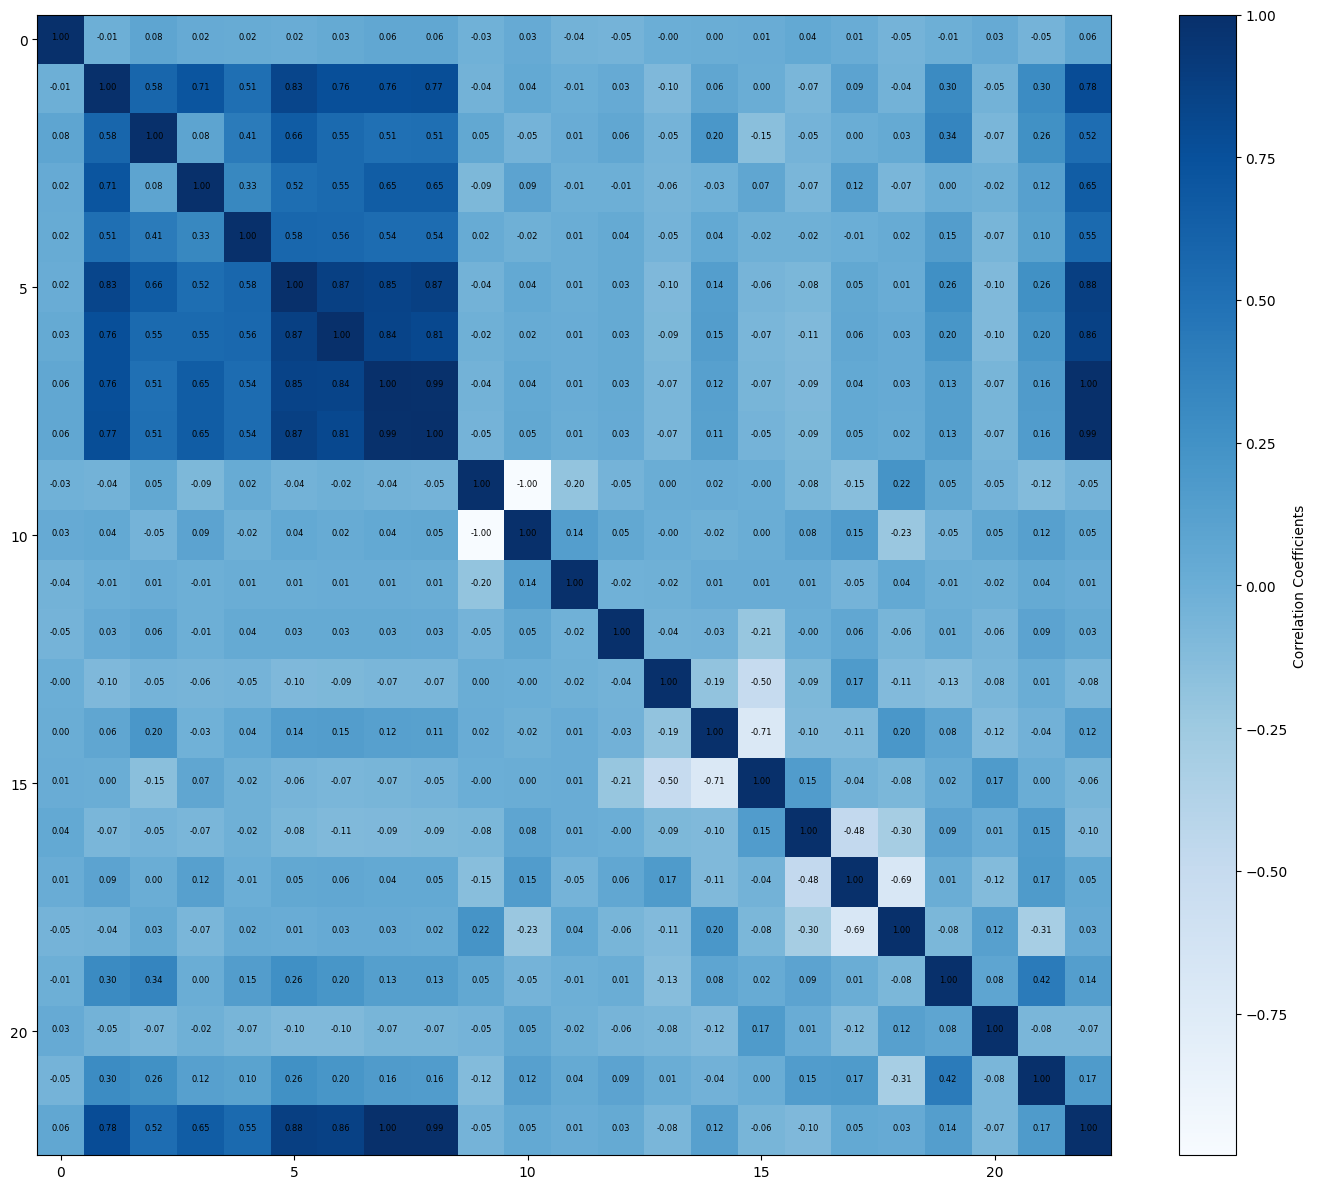

The high correlation between government shares and gross premium highlights the scheme's massive fiscal dependence on subsidies. The stronger link between non-loanee farmers and total counts suggests that policy awareness and voluntary trust are the real engines for growth in farmer participation, rather than institutional credit requirements.


In [146]:
# Correlation Study

numerical_cols = crop_insurance_df.select_dtypes(include = [np.number]).columns
correlation_matrix = crop_insurance_df[numerical_cols].corr()
print(correlation_matrix)

fig, ax = plt.subplots(figsize = (14, 12))
image = ax.imshow(correlation_matrix, cmap = 'Blues', aspect = 'auto')
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha = 'center', color = 'k', fontsize = 6)
plt.colorbar(image, ax = ax, label = 'Correlation Coefficients')
plt.tight_layout()
plt.show()
print("The high correlation between government shares and gross premium highlights the scheme's massive fiscal dependence on subsidies. The stronger link between non-loanee farmers and total counts suggests that policy awareness and voluntary trust are the real engines for growth in farmer participation, rather than institutional credit requirements.")

In [106]:
# The state that has the most and the least number of farmers

farmers_state = crop_insurance_df.groupby('state')['district.farmerCount'].sum()
print(f'The state with the most number of farmers is {farmers_state.idxmax()} with {farmers_state.max()} number of farmers.')
print(f'The state with the least number of farmers is {farmers_state.idxmin()} with {farmers_state.min()} number of farmers.')

The state with the most number of farmers is MAHARASHTRA with 17723648 number of farmers.
The state with the least number of farmers is SIKKIM with 283 number of farmers.


In [107]:
# The state that has the most loanee

loanee_state = crop_insurance_df.groupby('state')['district.application.loanee'].sum()
print(f'The state with the most number of loanee is {loanee_state.idxmax()} with {loanee_state.max()} number of loanee.')

The state with the most number of loanee is RAJASTHAN with 22569600.0 number of loanee.


In [109]:
# The district that has the most area insured

area_district = crop_insurance_df.groupby('district.districtName')['district.areaInsured (th.ha)'].sum()
print(f'The district with the most area insured is {area_district.idxmax()} with {area_district.max()} units.')

The district with the most area insured is Shimla with 8631.48 units.


In [148]:
# Assuming that I am employed as an agriculture officer for better farming policies.
# A detailed insight about the study from the above database

print('DETAILED INSIGHT\n')
farmer_participation = crop_insurance_df.groupby('year')['district.farmerCount'].sum().reset_index()
change = ((farmer_participation['district.farmerCount'].iloc[0]-farmer_participation['district.farmerCount'].iloc[-1])/farmer_participation['district.farmerCount'].iloc[0])*100
print(f"There's a {change:.2f}% decline in farmers' participation.")
print('This sharp decline suggests a potential "opt-out" by several states or the impact of the scheme becoming voluntary for loanee farmers starting in Kharif 2020.')
print('---------------------------------------------------------------')
area_covered = crop_insurance_df.groupby('year')['district.areaInsured (th.ha)'].sum().reset_index()
change = ((area_covered['district.areaInsured (th.ha)'].iloc[0]-area_covered['district.areaInsured (th.ha)'].iloc[-1])/area_covered['district.areaInsured (th.ha)'].iloc[0])*100
print(f"There's a {change:.2f}% decline in area insured, indicating a shrinkage in the safety net for major crops.")
print('---------------------------------------------------------------')
def weighted_avg(column_name, weight_col='district.farmerCount'):
    clean_df = crop_insurance_df.dropna(subset=[column_name])
    return (clean_df[column_name] * clean_df[weight_col]).sum() / clean_df[weight_col].sum()
male_pct = weighted_avg('district.gender.male (%)')
female_pct = weighted_avg('district.gender.female (%)')
sc_pct = weighted_avg('district.category.sc (%)')
st_pct = weighted_avg('district.category.st (%)')
obc_pct = weighted_avg('district.category.obc (%)')
gen_pct = weighted_avg('district.category.gen (%)')
marginal_pct = weighted_avg('district.type.marginal (%)')
small_pct = weighted_avg('district.type.small (%)')
other_pct = weighted_avg('district.type.other (%)')
print(f"Gender Gap: Male {male_pct:.1f}%, Female {female_pct:.1f}%")
print(f"Social Categories: SC {sc_pct:.1f}%, ST {st_pct:.1f}%, OBC {obc_pct:.1f}%, General {gen_pct:.1f}%")
print(f"Farmer Type: Small & Marginal {(small_pct + marginal_pct):.1f}%, Other {other_pct:.1f}%")
print('This reflects the existing challenge in land ownership title for women, SC and ST farmers.')
print('This also shows that the scheme successfully targeted the intended group, with majority beneficiaries being Small and Marginal Farmers.')
print('---------------------------------------------------------------')
regional_participation = crop_insurance_df.groupby('state')['district.farmerCount'].sum()
regional_participation = regional_participation.sort_values(ascending = False).reset_index()
print(regional_participation.head(3))
print('The high participation in these states is often linked to high-value cash crops and frequent climate-related risks.')
print('---------------------------------------------------------------')

# A better policy decision so that the government can provide better insurance to government
print('BETTER POLICY DECISION\n')
print('1. The government should consider a 100% premium subsidy (zero farmer share) specifically for female landholders and SC/ST farmers to bridge the inclusivity gap.')
print('2. Expedite the integration of insurance portals with digital land records to make it easier for marginalized farmers to enroll without excessive paperwork.')
print('3. Move towards Individual Farm-Level assessment using satellite imagery, remote sensing, and drone-based crop cutting experiments to ensure every affected farmer gets paid accurately.')
print('4. The government should use the database to provide real-time weather alerts and crop advisories to insured farmers. By preventing loss through better information, the overall claim ratio can be reduced, making the scheme more sustainable.')
print('5. For the WBCIS scheme, payouts should be automated based on weather station data (rainfall/temperature) without waiting for manual surveys. This ensures farmers receive funds immediately after a calamity to prepare for the next season.')

DETAILED INSIGHT

There's a 50.27% decline in farmers' participation.
This sharp decline suggests a potential "opt-out" by several states or the impact of the scheme becoming voluntary for loanee farmers starting in Kharif 2020.
---------------------------------------------------------------
There's a 38.67% decline in area insured, indicating a shrinkage in the safety net for major crops.
---------------------------------------------------------------
Gender Gap: Male 84.8%, Female 15.1%
Social Categories: SC 6.4%, ST 6.5%, OBC 41.1%, General 46.0%
Farmer Type: Small & Marginal 82.2%, Other 17.8%
This reflects the existing challenge in land ownership title for women, SC and ST farmers.
This also shows that the scheme successfully targeted the intended group, with majority beneficiaries being Small and Marginal Farmers.
---------------------------------------------------------------
            state  district.farmerCount
0     MAHARASHTRA              17723648
1  MADHYA PRADESH       

In [134]:
# Geographical Information (using GeoPandas)

state_summary = crop_insurance_df.groupby('state')['district.farmerCount'].sum().reset_index()
state_summary['state'] = state_summary['state'].str.title()
state_summary.to_csv('state_farmer_counts.csv', index = False)
print("Data aggregated by state and saved to 'state_farmer_counts.csv'.")

Data aggregated by state and saved to 'state_farmer_counts.csv'.


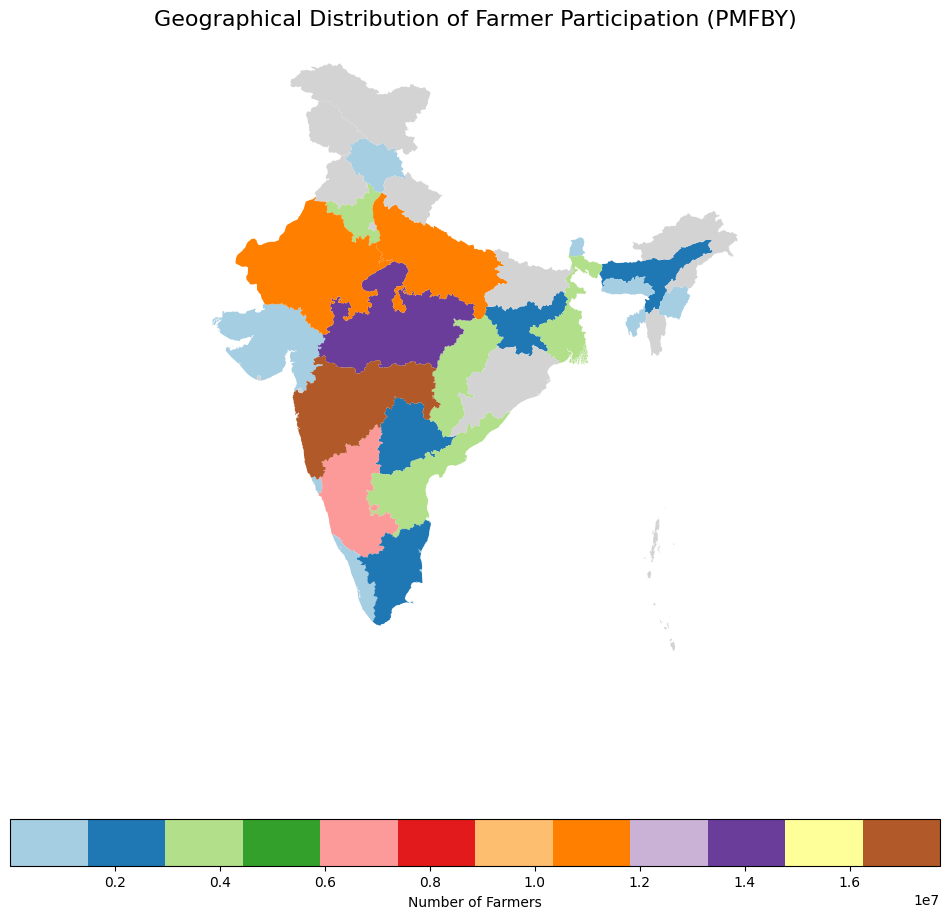

In [151]:
map_df = gpd.read_file('in.json')
state_data = pd.read_csv('state_farmer_counts.csv')
merged = map_df.merge(state_data, left_on='name', right_on='state', how='left')
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
merged.plot(column='district.farmerCount', ax=ax, legend=True, cmap='Paired', legend_kwds={'label': "Number of Farmers", 'orientation': "horizontal"},missing_kwds={'color': 'lightgrey'})
plt.title('Geographical Distribution of Farmer Participation (PMFBY)', fontsize=16)
ax.axis('off')
plt.show()

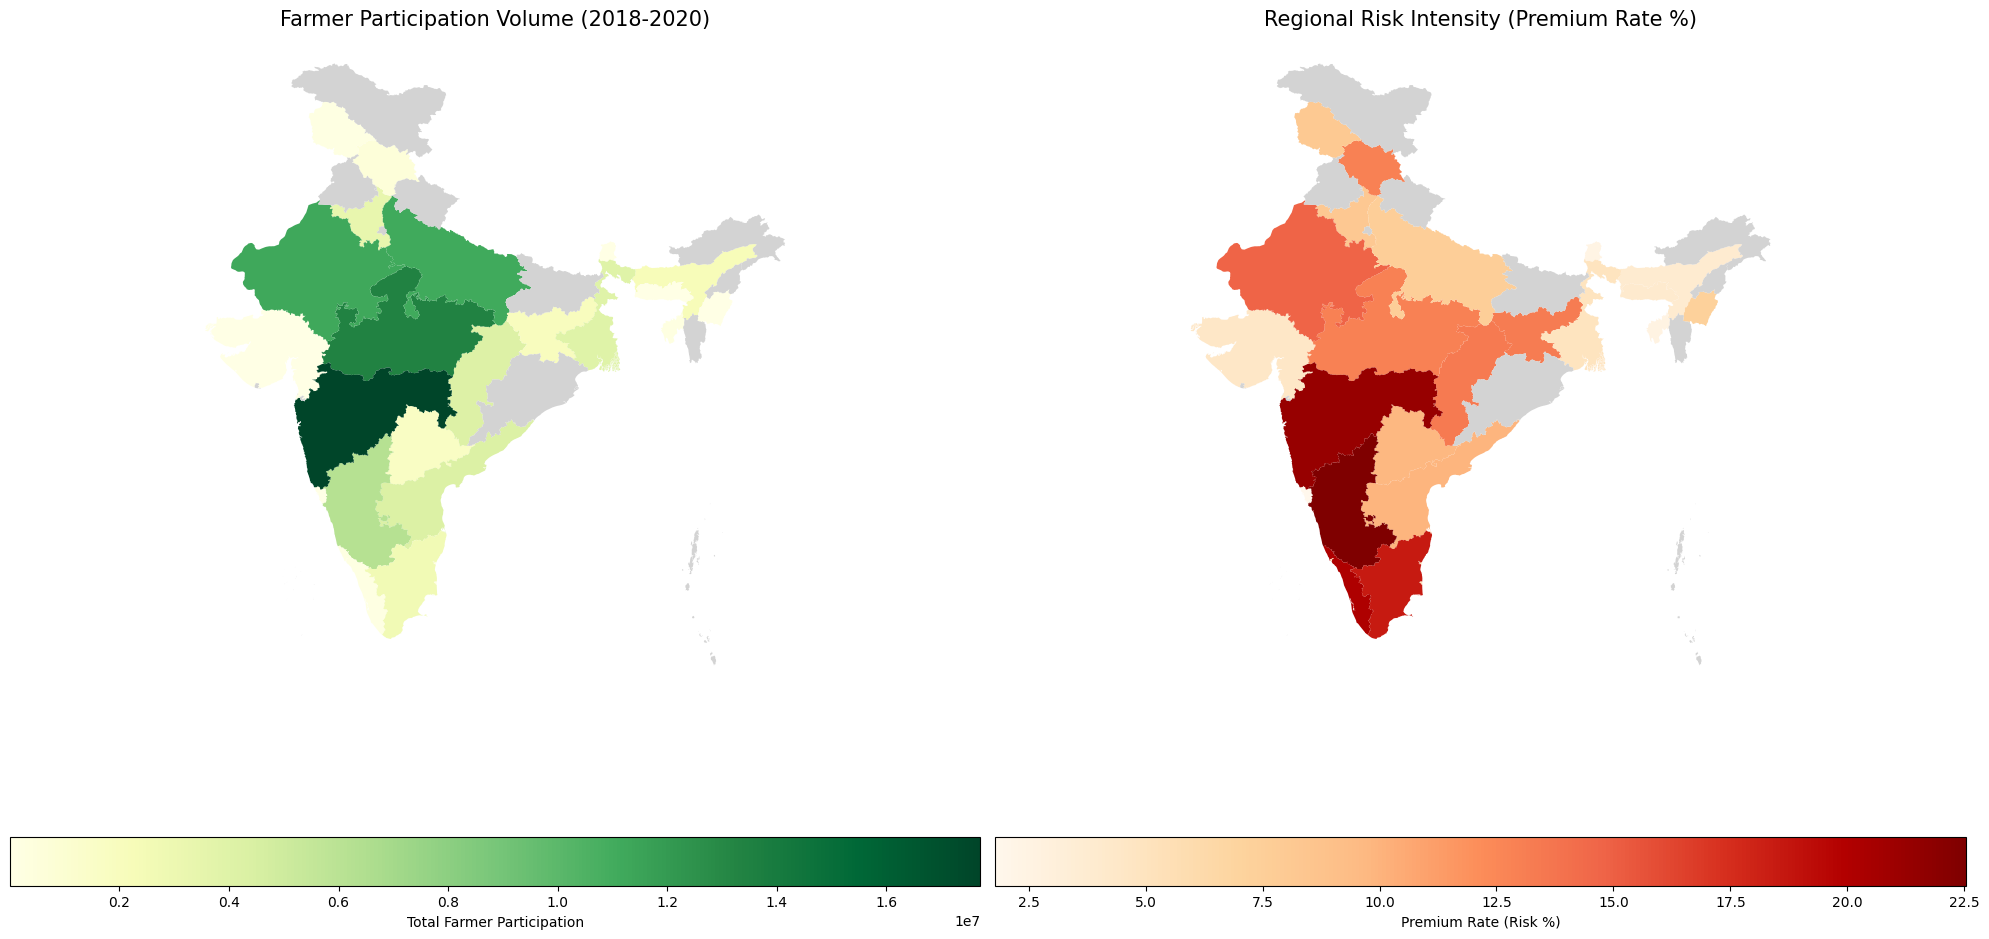

The map on the left represents the "Risk Intensity. We can observe that while participation is high in the central belt, the actual insurance risk is highest in the Southern and Western states (like Karnataka and Maharashtra), where premium rates are disproportionately high compared to northern states."


In [153]:
# More useful information in terms of geographical and graphical representation

state_agg = crop_insurance_df.groupby('state').agg({'district.farmerCount': 'sum', 'district.grossPremium (lac.)': 'sum', 'district.sumInsured (lac.)': 'sum'}).reset_index()
state_agg['premium_rate (%)'] = (state_agg['district.grossPremium (lac.)'] / state_agg['district.sumInsured (lac.)']) * 100
with open('in.json', 'r') as f:
    geojson_data = json.load(f)
gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])
gdf['name_upper'] = gdf['name'].str.upper()
state_agg['state_upper'] = state_agg['state'].str.upper()
merged = gdf.merge(state_agg, left_on='name_upper', right_on='state_upper', how='left')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
merged.plot(column='district.farmerCount', ax=ax1, legend=True, cmap='YlGn', legend_kwds={'label': "Total Farmer Participation", 'orientation': "horizontal"}, missing_kwds={'color': 'lightgrey'})
ax1.set_title('Farmer Participation Volume (2018-2020)', fontsize=15)
ax1.axis('off')
merged.plot(column='premium_rate (%)', ax=ax2, legend=True, cmap='OrRd', legend_kwds={'label': "Premium Rate (Risk %)", 'orientation': "horizontal"}, missing_kwds={'color': 'lightgrey'})
ax2.set_title('Regional Risk Intensity (Premium Rate %)', fontsize=15)
ax2.axis('off')
plt.tight_layout()
plt.show()
print('The map on the left represents the "Risk Intensity. We can observe that while participation is high in the central belt, the actual insurance risk is highest in the Southern and Western states (like Karnataka and Maharashtra), where premium rates are disproportionately high compared to northern states."')